## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import time
import platform
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing   import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve,
    matthews_corrcoef
)
from scipy import stats

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 11

# ── Device setup ──────────────────────────────────────────
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0 if platform.system() == 'Windows' else 2
PIN_MEMORY  = torch.cuda.is_available()

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"Platform        : {platform.system()}")
print(f"num_workers     : {NUM_WORKERS}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.13.0+cpu
Device          : cpu
Platform        : Windows
num_workers     : 0


## Load data

In [2]:
print("Loading dataset...")

# ── Load raw dataset ──────────────────────────────────────
df = pd.read_csv(
    r"C:\Users\tjain\Downloads\HI-Small_Trans.csv"
)

df = df.rename(columns={
    'Account'   : 'Sender Account',
    'Account.1' : 'Receiver Account',
    'From Bank' : 'Sender Bank ID',
    'To Bank'   : 'Receiver Bank ID'
})

print(f"Shape          : {df.shape}")
print(f"Fraud rows     : {df['Is Laundering'].sum():,}")
print(f"Normal rows    : {(df['Is Laundering']==0).sum():,}")

Loading dataset...
Shape          : (5078336, 32)
Fraud rows     : 5,177
Normal rows    : 5,073,159


## Define CNN features

In [3]:
# ------------------------------------------------------------------
# Build list of Autoencoder Features
# ------------------------------------------------------------------

# Recreate fmt_cols safely (in case kernel was restarted)
fmt_cols = [col for col in df.columns if col.startswith('fmt_')]

print(f"Found {len(fmt_cols)} Payment Format columns:")
print(fmt_cols)

# List of all candidate features
AE_FEATURES = [
    # Time Features
    'Hour',
    'Day',
    'DayOfWeek',
    'IsWeekend',

    # Amount Features
    'Amount_Paid_Log',
    'Amount_Received_Log',

    # Bank Features
    'Sender Bank ID',
    'Receiver Bank ID',

    # Encoded Account Features
    'Sender_Account_Encoded',
    'Receiver_Account_Encoded',
 # Transaction Flags
    'is_cross_bank',
    'is_self_transfer',
    'is_currency_mismatch',

    # Outlier Features
    'is_amount_outlier_iqr',
    'is_amount_outlier_zscore',
    'is_account_level_outlier',
    'outlier_score',
    'is_outlier',

    # Velocity Features
    'is_high_velocity',
    'amount_vs_account_median',
    'txn_count_per_sender_hour',
    'txn_count_per_sender_day',

    # Currency Features
    'Payment_Currency_Encoded',
    'Receiving_Currency_Encoded',
] + fmt_cols

# ------------------------------------------------------------------
# Keep only columns that actually exist in the dataframe
# and remove duplicates
# ------------------------------------------------------------------
seen = set()

AE_FEATURES = [
    feature
    for feature in AE_FEATURES
    if feature in df.columns and not (feature in seen or seen.add(feature))
]

# ------------------------------------------------------------------
# Display final feature list
# ------------------------------------------------------------------

INPUT_DIM = len(AE_FEATURES)

print("\n" + "=" * 50)
print(f"Total Autoencoder Features: {INPUT_DIM}")
print("=" * 50)

for i, feature in enumerate(AE_FEATURES, start=1):
    print(f"{i:2d}. {feature}")

# Optional: Create feature matrix for Autoencoder
X_ae = df[AE_FEATURES]
print("\nFeature Matrix Shape:")
print(X_ae.shape)

Found 7 Payment Format columns:
['fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire']

Total Autoencoder Features: 29
 1. Hour
 2. Day
 3. DayOfWeek
 4. IsWeekend
 5. Sender Bank ID
 6. Receiver Bank ID
 7. Sender_Account_Encoded
 8. Receiver_Account_Encoded
 9. is_cross_bank
10. is_self_transfer
11. is_currency_mismatch
12. is_amount_outlier_iqr
13. is_amount_outlier_zscore
14. is_account_level_outlier
15. outlier_score
16. is_outlier
17. is_high_velocity
18. amount_vs_account_median
19. txn_count_per_sender_hour
20. txn_count_per_sender_day
21. Payment_Currency_Encoded
22. Receiving_Currency_Encoded
23. fmt_ACH
24. fmt_Bitcoin
25. fmt_Cash
26. fmt_Cheque
27. fmt_Credit Card
28. fmt_Reinvestment
29. fmt_Wire

Feature Matrix Shape:
(5078336, 29)


In [4]:
# ══════════════════════════════════════════════════════════
# CNN FEATURES
# ══════════════════════════════════════════════════════════
# FIX: the previous list used names that do not exist in the
# cleaned dataset ('Amount_Paid_Log', 'Sender_Enc', 'IsNight',
# 'txn_count_per_hour' ...). The "keep only existing columns"
# filter then silently dropped them — including EVERY amount
# feature — so the CNN was trained blind to transaction value.
# These are the real column names, with the log-amounts built
# here if they are missing.
# ══════════════════════════════════════════════════════════

# Build the log-amount features the CNN needs
if 'Amount_Paid_Log' not in df.columns:
    df['Amount_Paid_Log'] = np.log1p(df['Amount Paid'])
if 'Amount_Received_Log' not in df.columns:
    df['Amount_Received_Log'] = np.log1p(df['Amount Received'])
if 'Amount_Diff_Log' not in df.columns:
    df['Amount_Diff_Log'] = np.log1p(
        (df['Amount Paid'] - df['Amount Received']).abs()
    )

fmt_cols = [c for c in df.columns if c.startswith('fmt_')]

CNN_FEATURES = [
    # Amount signals  ← these were missing before
    'Amount_Paid_Log', 'Amount_Received_Log', 'Amount_Diff_Log',
    'amount_vs_account_median',

    # Time
    'Hour', 'Day', 'DayOfWeek', 'IsWeekend',

    # Bank / routing
    'Sender Bank ID', 'Receiver Bank ID',
    'is_cross_bank', 'is_self_transfer', 'is_currency_mismatch',

    # Outlier flags
    'is_amount_outlier_iqr', 'is_amount_outlier_zscore',
    'is_account_level_outlier', 'outlier_score', 'is_outlier',

    # Velocity  (real column names)
    'is_high_velocity',
    'txn_count_per_sender_hour', 'txn_count_per_sender_day',

    # Currency encodings
    'Payment_Currency_Encoded', 'Receiving_Currency_Encoded',
] + fmt_cols

missing = [f for f in CNN_FEATURES if f not in df.columns]
if missing:
    raise ValueError(f"These CNN features are missing from df: {missing}")

seen = set()
CNN_FEATURES = [f for f in CNN_FEATURES if not (f in seen or seen.add(f))]

INPUT_SIZE_CNN = len(CNN_FEATURES)

# ── MUST MATCH THE LSTM NOTEBOOK ──────────────────────────
# The notebooks claim a "fair comparison", but the CNN used
# SEQUENCE_LEN=15 / 8000 accounts while the LSTM used 10 / 5000 —
# so the two models were never compared on the same data.
# Both are now 10 and 8000. Using 10 instead of 15 also means an
# account needs only 11 transactions to qualify instead of 16, so
# far fewer accounts are skipped and coverage improves.
SEQUENCE_LEN   = 10

print(f"CNN features   : {INPUT_SIZE_CNN}   (was 22 — amount features had been dropped)")
print(f"Sequence length: {SEQUENCE_LEN}")
for i, f in enumerate(CNN_FEATURES, 1):
    print(f"  {i:2}. {f}")


CNN features   : 30   (was 22 — amount features had been dropped)
Sequence length: 10
   1. Amount_Paid_Log
   2. Amount_Received_Log
   3. Amount_Diff_Log
   4. amount_vs_account_median
   5. Hour
   6. Day
   7. DayOfWeek
   8. IsWeekend
   9. Sender Bank ID
  10. Receiver Bank ID
  11. is_cross_bank
  12. is_self_transfer
  13. is_currency_mismatch
  14. is_amount_outlier_iqr
  15. is_amount_outlier_zscore
  16. is_account_level_outlier
  17. outlier_score
  18. is_outlier
  19. is_high_velocity
  20. txn_count_per_sender_hour
  21. txn_count_per_sender_day
  22. Payment_Currency_Encoded
  23. Receiving_Currency_Encoded
  24. fmt_ACH
  25. fmt_Bitcoin
  26. fmt_Cash
  27. fmt_Cheque
  28. fmt_Credit Card
  29. fmt_Reinvestment
  30. fmt_Wire


## Scale features

In [5]:
print(df.columns)

Index(['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID',
       'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded',
       'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid',
       'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch',
       'is_amount_outlier_iqr', 'is_amount_outlier_zscore',
       'is_account_level_outlier', 'is_high_velocity', 'outlier_score',
       'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day',
       'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card',
       'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded',
       'Receiving_Currency_Encoded', 'Is Laundering', 'Amount_Paid_Log',
       'Amount_Received_Log', 'Amount_Diff_Log'],
      dtype='object')


In [6]:
# ══════════════════════════════════════════════════════════
# ACCOUNT-LEVEL SPLIT  +  LEAK-FREE SCALING
# ══════════════════════════════════════════════════════════
# FIX 1 (leakage): the scaler was previously fitted on the WHOLE
#   dataframe before the train/test split, so it saw test data.
# FIX 2 (leakage): sequences were split randomly, which puts
#   overlapping windows from the SAME account in both train and
#   test. We now split by ACCOUNT so no account appears in both.
# ══════════════════════════════════════════════════════════

MAX_ACCOUNTS = 8000   # raise for more coverage (costs training time)

df = df.sort_values(['Sender_Account_Encoded']).reset_index(drop=True)

all_accounts = df['Sender_Account_Encoded'].unique()[:MAX_ACCOUNTS]

rng = np.random.RandomState(42)
shuffled = rng.permutation(all_accounts)
n_train_acc   = int(len(shuffled) * 0.8)
train_accounts = set(shuffled[:n_train_acc])
test_accounts  = set(shuffled[n_train_acc:])

print(f"Accounts used  : {len(all_accounts):,}")
print(f"  train accounts: {len(train_accounts):,}")
print(f"  test accounts : {len(test_accounts):,}")

# Fit the scaler ONLY on training-account rows, then transform everything
train_row_mask = df['Sender_Account_Encoded'].isin(train_accounts)

scaler_cnn = RobustScaler()
scaler_cnn.fit(df.loc[train_row_mask, CNN_FEATURES].fillna(0))
df[CNN_FEATURES] = scaler_cnn.transform(df[CNN_FEATURES].fillna(0))

print("Scaling done — scaler fitted on TRAIN ACCOUNTS ONLY (no leakage).")
print(f"Features scaled: {INPUT_SIZE_CNN}")


Accounts used  : 8,000
  train accounts: 6,400
  test accounts : 1,600
Scaling done — scaler fitted on TRAIN ACCOUNTS ONLY (no leakage).
Features scaled: 30


## Build sequences

In [7]:
# ══════════════════════════════════════════════════════════
# CNN SEQUENCE BUILDING  (train/test tagged by account)
# ══════════════════════════════════════════════════════════

print(f"Building CNN sequences (length={SEQUENCE_LEN})...")

sequences, labels, account_ids, is_train = [], [], [], []

grouped  = df.groupby('Sender_Account_Encoded')
acc_list = list(all_accounts)
skipped  = 0

for acc in acc_list:
    acc_df = grouped.get_group(acc).reset_index(drop=True)
    if len(acc_df) < SEQUENCE_LEN + 1:
        skipped += 1
        continue

    feats = acc_df[CNN_FEATURES].values.astype(np.float32)
    lbls  = acc_df['Is Laundering'].values
    in_train = acc in train_accounts

    for i in range(len(acc_df) - SEQUENCE_LEN):
        sequences.append(feats[i:i + SEQUENCE_LEN])
        labels.append(lbls[i + SEQUENCE_LEN])
        account_ids.append(acc)
        is_train.append(in_train)

sequences   = np.array(sequences, dtype=np.float32)
labels      = np.array(labels,    dtype=np.float32)
account_ids = np.array(account_ids)
is_train    = np.array(is_train,  dtype=bool)

# (N, seq_len, features) -> (N, features, seq_len)
sequences_cnn = sequences.transpose(0, 2, 1)

print(f"\nSequences built    : {len(sequences_cnn):,}")
print(f"CNN input shape    : {sequences_cnn.shape}")
print(f"Fraud sequences    : {int(labels.sum()):,} ({labels.mean()*100:.3f}%)")
print(f"Accounts skipped   : {skipped:,}")
print(f"Train sequences    : {is_train.sum():,}")
print(f"Test sequences     : {(~is_train).sum():,}")


Building CNN sequences (length=10)...

Sequences built    : 731,585
CNN input shape    : (731585, 30, 10)
Fraud sequences    : 882 (0.121%)
Accounts skipped   : 3,768
Train sequences    : 621,172
Test sequences     : 110,413


## Train test and split

In [8]:
# ══════════════════════════════════════════════════════════
# TRAIN / TEST SPLIT  — by ACCOUNT (no window overlap leakage)
# ══════════════════════════════════════════════════════════
# FIX: train_test_split() on sequences put overlapping windows
# from the same account into both sets. We use the account-level
# masks built above instead.

X_train_cnn = sequences_cnn[is_train]
X_test_cnn  = sequences_cnn[~is_train]
y_train_cnn = labels[is_train]
y_test_cnn  = labels[~is_train]

print("Train/Test split done (by account)!")
print(f"X_train_cnn : {X_train_cnn.shape}")
print(f"X_test_cnn  : {X_test_cnn.shape}")
print(f"Fraud train : {y_train_cnn.sum():,.0f} ({y_train_cnn.mean()*100:.3f}%)")
print(f"Fraud test  : {y_test_cnn.sum():,.0f}  ({y_test_cnn.mean()*100:.3f}%)")


Train/Test split done (by account)!
X_train_cnn : (621172, 30, 10)
X_test_cnn  : (110413, 30, 10)
Fraud train : 751 (0.121%)
Fraud test  : 131  (0.119%)


## Pytorch dataset

In [9]:
class CNNSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.FloatTensor(sequences)   # (N, features, seq_len)
        self.y = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE_CNN = 512

train_dataset_cnn = CNNSequenceDataset(X_train_cnn, y_train_cnn)
test_dataset_cnn  = CNNSequenceDataset(X_test_cnn,  y_test_cnn)

# Weighted sampler for class imbalance
fraud_count  = int(y_train_cnn.sum())
normal_count = int((y_train_cnn == 0).sum())
weights      = [1.0/normal_count if l==0 else 1.0/fraud_count
                for l in y_train_cnn]

from torch.utils.data import WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights     = weights,
    num_samples = len(weights),
    replacement = True
)

train_loader_cnn = DataLoader(
    train_dataset_cnn,
    batch_size  = BATCH_SIZE_CNN,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY
)

test_loader_cnn = DataLoader(
    test_dataset_cnn,
    batch_size  = BATCH_SIZE_CNN,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY
)

print("CNN DataLoaders created!")
print(f"Train batches : {len(train_loader_cnn):,}")
print(f"Test batches  : {len(test_loader_cnn):,}")

CNN DataLoaders created!
Train batches : 1,214
Test batches  : 216


## CNN-1D model architechture

In [10]:
# ════════════════════════════════════════════════════════
# CNN-1D ARCHITECTURE FOR AML DETECTION
# ════════════════════════════════════════════════════════
#
# HOW CNN-1D WORKS ON TRANSACTIONS:
#
# Input: SEQUENCE_LEN transactions × INPUT_SIZE_CNN features
# CNN sees this as a 1D signal with 30 channels
#
# CONV LAYER with kernel_size=3 means:
# "Look at 3 consecutive transactions at once"
# It learns patterns like:
# "large amount + night + cross_bank = suspicious burst"
# "3 small + 1 large = structuring pattern"
#
# Why multiple kernel sizes (3, 5, 7)?
# kernel_size=3 → detects short 3-step patterns
# kernel_size=5 → detects medium 5-step patterns
# kernel_size=7 → detects longer 7-step patterns
# Combining all three = multi-scale pattern detection
#
# GLOBAL MAX POOLING:
# From each filter's output, take the MAXIMUM value
# "What is the most suspicious moment in the sequence?"
#
# This is called MULTI-SCALE CNN or TextCNN architecture
# originally designed for text — works perfectly for
# transaction sequences
#
# Architecture:
# Input (batch, INPUT_SIZE_CNN, SEQUENCE_LEN)
#   ↓ Conv1D(32 filters, k=3) → MaxPool → (batch, 32)
#   ↓ Conv1D(32 filters, k=5) → MaxPool → (batch, 32)
#   ↓ Conv1D(32 filters, k=7) → MaxPool → (batch, 32)
#   ↓ Concatenate → (batch, 96)
#   ↓ FC(64) → FC(32) → FC(1) → raw logit
# ════════════════════════════════════════════════════════

class AMLConv1D(nn.Module):
    def __init__(self, input_channels, seq_len, dropout_rate=0.3):
        super(AMLConv1D, self).__init__()

        num_filters = 64   # filters per kernel size

        # ── Branch 1: kernel_size=3 ───────────────────
        # Detects short-term burst patterns (3 transactions)
        self.conv3 = nn.Sequential(
            nn.Conv1d(
                in_channels  = input_channels,
                out_channels = num_filters,
                kernel_size  = 3,
                padding      = 1        # keep sequence length same
            ),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.Conv1d(
                in_channels  = num_filters,
                out_channels = num_filters,
                kernel_size  = 3,
                padding      = 1
            ),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)     # global max: (batch, 64, 1)
        )

        # ── Branch 2: kernel_size=5 ───────────────────
        # Detects medium-term patterns (5 transactions)
        self.conv5 = nn.Sequential(
            nn.Conv1d(
                in_channels  = input_channels,
                out_channels = num_filters,
                kernel_size  = 5,
                padding      = 2
            ),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.Conv1d(
                in_channels  = num_filters,
                out_channels = num_filters,
                kernel_size  = 5,
                padding      = 2
            ),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )

        # ── Branch 3: kernel_size=7 ───────────────────
        # Detects longer-term patterns (7 transactions)
        self.conv7 = nn.Sequential(
            nn.Conv1d(
                in_channels  = input_channels,
                out_channels = num_filters,
                kernel_size  = min(7, seq_len),
                padding      = min(3, seq_len//2)
            ),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.Conv1d(
                in_channels  = num_filters,
                out_channels = num_filters,
                kernel_size  = min(7, seq_len),
                padding      = min(3, seq_len//2)
            ),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )

        # ── Combine all 3 branches ────────────────────
        combined_size = num_filters * 3   # 64 * 3 = 192

        # ── Fully connected classifier ────────────────
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),

            nn.Linear(32, 1),
            # FIX: no Sigmoid here — the model returns RAW LOGITS.
            # nn.BCEWithLogitsLoss applies the sigmoid internally and
            # is numerically stable; torch.sigmoid() is used only when
            # we need probabilities at evaluation time.
        )

    def forward(self, x):
        # x shape: (batch, input_channels, seq_len)
        # e.g.   : (512, 30, 15)

        # Pass through each branch
        out3 = self.conv3(x).squeeze(-1)   # (batch, 64)
        out5 = self.conv5(x).squeeze(-1)   # (batch, 64)
        out7 = self.conv7(x).squeeze(-1)   # (batch, 64)

        # Concatenate all branches
        combined = torch.cat([out3, out5, out7], dim=1)
        # combined shape: (batch, 192)

        # Classify
        output = self.classifier(combined)
        return output.squeeze(1)            # (batch,)


# ── Create model ──────────────────────────────────────────
model_cnn = AMLConv1D(
    input_channels = INPUT_SIZE_CNN,
    seq_len        = SEQUENCE_LEN,
    dropout_rate   = 0.3
).to(device)

total_params = sum(p.numel() for p in model_cnn.parameters())
print("CNN-1D Model Architecture:")
print("=" * 55)
print(model_cnn)
print("=" * 55)
print(f"\nInput shape      : (batch, {INPUT_SIZE_CNN}, {SEQUENCE_LEN})")
print(f"Total parameters : {total_params:,}")
print(f"Device           : {device}")
print(f"\nWhy 3 branches?")
print(f"  Branch k=3 : detects 3-transaction burst patterns")
print(f"  Branch k=5 : detects 5-transaction medium patterns")
print(f"  Branch k=7 : detects 7-transaction longer patterns")
print(f"  Combined   : catches fraud at ALL time scales")

CNN-1D Model Architecture:
AMLConv1D(
  (conv3): Sequential(
    (0): Conv1d(30, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveMaxPool1d(output_size=1)
  )
  (conv5): Sequential(
    (0): Conv1d(30, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveMaxPool1d(output_size=1)
  )
  (conv7): Sequential(
    (0): Conv1d(30, 64, kernel_size=(7,), stride=(1,), paddin

## Loss,optimizer,scheduler

In [11]:
# ── Class weight for imbalance ────────────────────────────
pos_weight_val = normal_count / fraud_count
pos_weight     = torch.tensor([pos_weight_val]).to(device)

# FIX: nn.BCELoss() accepts NO pos_weight argument, so the 828:1
# class weight computed above was never actually applied to the
# loss. BCEWithLogitsLoss does accept it — and expects logits,
# which the model now returns.
criterion_cnn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_cnn = optim.Adam(
    model_cnn.parameters(),
    lr           = 0.001,
    weight_decay = 1e-4
)

scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn,
    T_max = 20,      # cosine cycle length
    eta_min = 1e-5   # minimum learning rate
)

print(f"Loss function    : BCEWithLogitsLoss(pos_weight={pos_weight_val:.2f})")
print(f"Optimizer        : Adam (lr=0.001, wd=1e-4)")
print(f"Scheduler        : CosineAnnealingLR")
print(f"pos_weight       : {pos_weight_val:.2f}")
print(f"\nNote: CosineAnnealingLR is better than ReduceLROnPlateau")
print(f"for CNN because it smoothly cycles the learning rate")
print(f"helping escape local minima in the loss landscape")

Loss function    : BCEWithLogitsLoss(pos_weight=826.13)
Optimizer        : Adam (lr=0.001, wd=1e-4)
Scheduler        : CosineAnnealingLR
pos_weight       : 826.13

Note: CosineAnnealingLR is better than ReduceLROnPlateau
for CNN because it smoothly cycles the learning rate
helping escape local minima in the loss landscape


In [12]:
print("X_train_seq_cnn" in globals())
print("X_test_seq_cnn" in globals())

False
False


## Training loop

In [13]:
EPOCHS_CNN = 5

train_losses_cnn = []
val_auc_rocs_cnn = []
val_auc_prs_cnn  = []
best_auc_pr_cnn  = 0.0
best_epoch_cnn   = 0

print(f"Training CNN-1D for {EPOCHS_CNN} epochs...")
print(f"Device     : {device}")
print(f"Batch size : {BATCH_SIZE_CNN}")
print("=" * 65)

for epoch in range(EPOCHS_CNN):
    t0 = time.time()

    # ── Training ──────────────────────────────────────────
    model_cnn.train()
    total_loss = 0.0
    n_batches  = 0

    for batch_X, batch_y in train_loader_cnn:
        batch_X = batch_X.to(device)   # (batch, features, seq_len)
        batch_y = batch_y.to(device)

        optimizer_cnn.zero_grad()
        preds = model_cnn(batch_X)
        loss  = criterion_cnn(preds, batch_y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_cnn.parameters(), max_norm=1.0
        )
        optimizer_cnn.step()

        total_loss += loss.item()
        n_batches  += 1

    avg_train_loss = total_loss / n_batches
    train_losses_cnn.append(avg_train_loss)
    scheduler_cnn.step()

    # ── Validation ────────────────────────────────────────
    model_cnn.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader_cnn:
            batch_X = batch_X.to(device)
            # model returns logits -> convert to probabilities
            probs   = torch.sigmoid(model_cnn(batch_X))
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch_y.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    val_auc_roc = roc_auc_score(all_labels, all_probs)
    val_auc_pr  = average_precision_score(all_labels, all_probs)
    val_auc_rocs_cnn.append(val_auc_roc)
    val_auc_prs_cnn.append(val_auc_pr)

    is_best = val_auc_pr > best_auc_pr_cnn
    if is_best:
        best_auc_pr_cnn  = val_auc_pr
        best_auc_roc_cnn = val_auc_roc
        best_epoch_cnn   = epoch + 1
        torch.save(model_cnn.state_dict(), 'cnn_best_model.pt')

    epoch_time = time.time() - t0
    print(
        f"Epoch {epoch+1:2}/{EPOCHS_CNN} | "
        f"Loss: {avg_train_loss:.4f} | "
        f"AUC-ROC: {val_auc_roc:.4f} | "
        f"AUC-PR: {val_auc_pr:.4f} | "
        f"Time: {epoch_time:.1f}s"
        f"{'  ← BEST' if is_best else ''}"
    )

print(f"\nTraining complete!")
print(f"Best AUC-PR  : {best_auc_pr_cnn:.4f} at epoch {best_epoch_cnn}")
print(f"Best AUC-ROC : {best_auc_roc_cnn:.4f}")

Training CNN-1D for 5 epochs...
Device     : cpu
Batch size : 512
Epoch  1/5 | Loss: 12.7479 | AUC-ROC: 0.5874 | AUC-PR: 0.0019 | Time: 102.7s  ← BEST
Epoch  2/5 | Loss: 3.6071 | AUC-ROC: 0.5120 | AUC-PR: 0.0013 | Time: 102.3s
Epoch  3/5 | Loss: 3.0862 | AUC-ROC: 0.5665 | AUC-PR: 0.0017 | Time: 103.2s
Epoch  4/5 | Loss: 2.9289 | AUC-ROC: 0.5190 | AUC-PR: 0.0014 | Time: 103.1s
Epoch  5/5 | Loss: 2.8181 | AUC-ROC: 0.4875 | AUC-PR: 0.0017 | Time: 102.4s

Training complete!
Best AUC-PR  : 0.0019 at epoch 1
Best AUC-ROC : 0.5874


## Training progress chart

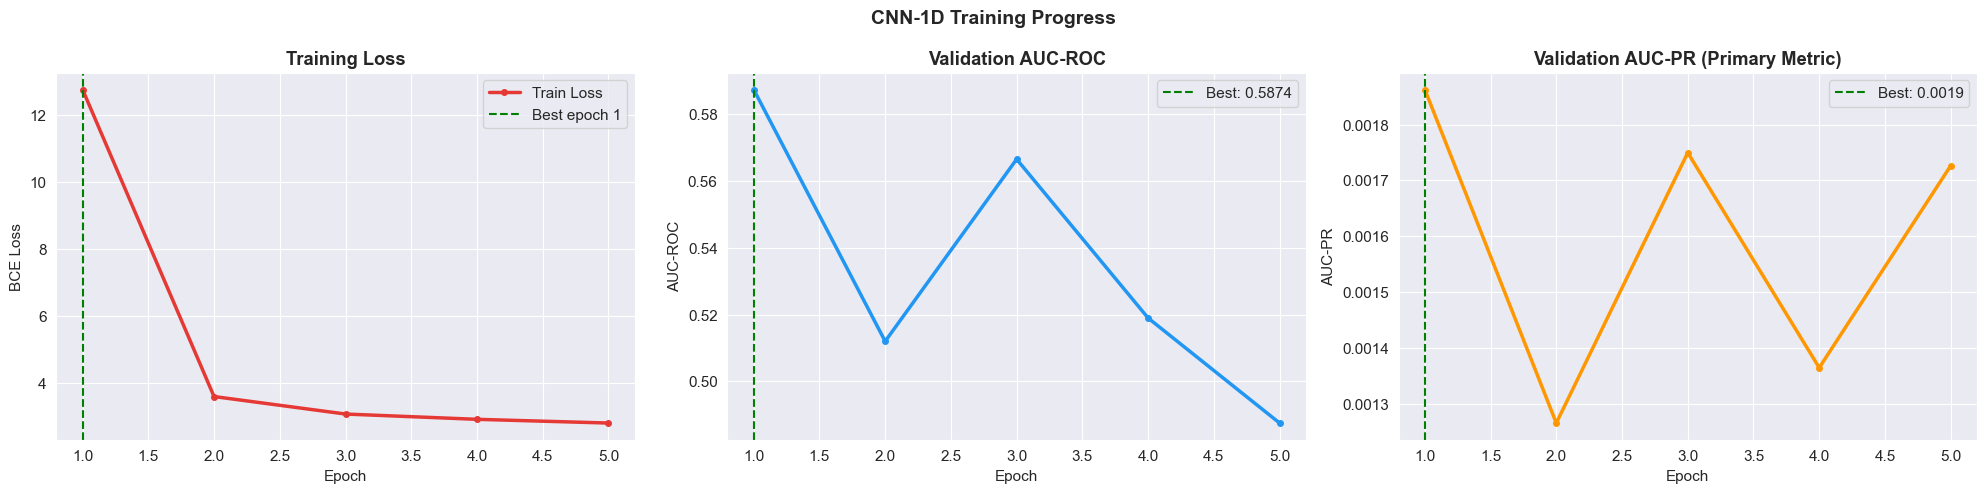

Training charts saved!


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('CNN-1D Training Progress', fontsize=14, fontweight='bold')

epochs_x = range(1, EPOCHS_CNN + 1)

axes[0].plot(epochs_x, train_losses_cnn, color='#E53935', linewidth=2.5,
             marker='o', markersize=4, label='Train Loss')
axes[0].axvline(x=best_epoch_cnn, color='green', linestyle='--',
                linewidth=1.5, label=f'Best epoch {best_epoch_cnn}')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(epochs_x, val_auc_rocs_cnn, color='#2196F3', linewidth=2.5,
             marker='o', markersize=4)
axes[1].axvline(x=best_epoch_cnn, color='green', linestyle='--',
                linewidth=1.5, label=f'Best: {best_auc_roc_cnn:.4f}')
axes[1].set_title('Validation AUC-ROC', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

axes[2].plot(epochs_x, val_auc_prs_cnn, color='#FF9800', linewidth=2.5,
             marker='o', markersize=4)
axes[2].axvline(x=best_epoch_cnn, color='green', linestyle='--',
                linewidth=1.5, label=f'Best: {best_auc_pr_cnn:.4f}')
axes[2].set_title('Validation AUC-PR (Primary Metric)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC-PR')
axes[2].legend()

plt.tight_layout()
plt.savefig('cnn_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training charts saved!")

## Load best model and evaluate

In [ ]:
print("Loading best CNN checkpoint...")
model_cnn.load_state_dict(
    torch.load('cnn_best_model.pt', map_location=device)
)
model_cnn.eval()

y_proba_cnn = []
y_true_cnn  = []

with torch.no_grad():
    for batch_X, batch_y in test_loader_cnn:
        batch_X = batch_X.to(device)
        # model returns logits -> convert to probabilities
        probs   = torch.sigmoid(model_cnn(batch_X))
        y_proba_cnn.extend(probs.cpu().numpy())
        y_true_cnn.extend(batch_y.numpy())

y_proba_cnn = np.array(y_proba_cnn)
y_true_cnn  = np.array(y_true_cnn)

# Default threshold
y_pred_default = (y_proba_cnn >= 0.5).astype(int)

# Best threshold by F1
prec_v, rec_v, thresh_v = precision_recall_curve(y_true_cnn, y_proba_cnn)
f1_list = []
for t in thresh_v:
    p = (y_proba_cnn >= t).astype(int)
    f1_list.append(f1_score(y_true_cnn, p, zero_division=0) if p.sum() > 0 else 0)

best_idx_cnn   = int(np.argmax(f1_list))
best_thresh_cnn= float(thresh_v[best_idx_cnn])
y_pred_cnn     = (y_proba_cnn >= best_thresh_cnn).astype(int)

# Metrics
auc_roc_cnn   = roc_auc_score(y_true_cnn, y_proba_cnn)
auc_pr_cnn    = average_precision_score(y_true_cnn, y_proba_cnn)
f1_cnn        = f1_score(y_true_cnn, y_pred_cnn, zero_division=0)
precision_cnn = precision_score(y_true_cnn, y_pred_cnn, zero_division=0)
recall_cnn    = recall_score(y_true_cnn, y_pred_cnn)
mcc_cnn       = matthews_corrcoef(y_true_cnn, y_pred_cnn)
cm_cnn        = confusion_matrix(y_true_cnn, y_pred_cnn)
tn, fp, fn, tp = cm_cnn.ravel()

print("=" * 55)
print("CNN-1D FINAL PERFORMANCE")
print("=" * 55)
print(f"\nAUC-ROC   : {auc_roc_cnn:.4f}")
print(f"AUC-PR    : {auc_pr_cnn:.4f}")
print(f"Recall    : {recall_cnn:.4f}  ({tp} caught / {int(y_true_cnn.sum())} fraud)")
print(f"Precision : {precision_cnn:.4f}")
print(f"F1 Score  : {f1_cnn:.4f}")
print(f"MCC       : {mcc_cnn:.4f}")
print(f"Threshold : {best_thresh_cnn:.4f}")
print(f"\nFraud caught  : {tp}")
print(f"Fraud missed  : {fn}")
print(f"False alarms  : {fp:,}")

print("\nClassification Report:")
print(classification_report(
    y_true_cnn, y_pred_cnn,
    target_names=['Normal','Fraud'],
    digits=4
))

Loading best CNN checkpoint...


## full performance and visualization

In [ ]:
fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    'CNN-1D — Multi-Scale Convolutional AML Detection\n'
    'Kernel sizes: 3, 5, 7 transactions — Multi-scale pattern detection',
    fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Chart 1: Confusion matrix ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_cnn, annot=True, fmt=',', cmap='Blues', ax=ax1,
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'],
            linewidths=0.5, annot_kws={'size':11,'weight':'bold'})
ax1.set_title(f'Confusion Matrix\n(threshold={best_thresh_cnn:.3f})', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# ── Chart 2: ROC curve ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
fpr_c, tpr_c, _ = roc_curve(y_true_cnn, y_proba_cnn)
ax2.plot(fpr_c, tpr_c, color='#9C27B0', linewidth=2.5,
         label=f'CNN-1D (AUC={auc_roc_cnn:.4f})')
ax2.plot([0,1],[0,1],'--', color='gray', linewidth=1, label='Random')
ax2.fill_between(fpr_c, tpr_c, alpha=0.1, color='#9C27B0')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.legend(); ax2.set_xlim([0,1]); ax2.set_ylim([0,1.05])

# ── Chart 3: PR curve ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(rec_v, prec_v, color='#FF9800', linewidth=2.5,
         label=f'CNN-1D (AP={auc_pr_cnn:.4f})')
bl = y_true_cnn.mean()
ax3.axhline(bl, color='gray', linestyle='--', linewidth=1,
            label=f'Baseline ({bl:.4f})')
ax3.fill_between(rec_v, prec_v, alpha=0.1, color='#FF9800')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.legend(); ax3.set_xlim([0,1]); ax3.set_ylim([0,1.05])

# ── Chart 4: Score distribution ───────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_proba_cnn[y_true_cnn==0], bins=60, color='#2196F3',
         alpha=0.6, label='Normal', density=True)
ax4.hist(y_proba_cnn[y_true_cnn==1], bins=60, color='#E53935',
         alpha=0.6, label='Fraud',  density=True)
ax4.axvline(x=best_thresh_cnn, color='black', linestyle='--',
            linewidth=2, label=f'Threshold={best_thresh_cnn:.3f}')
ax4.set_title('CNN Fraud Score Distribution', fontweight='bold')
ax4.set_xlabel('Fraud Probability')
ax4.set_ylabel('Density')
ax4.legend()

# ── Chart 5: F1 by threshold ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(thresh_v, f1_list, color='#4CAF50', linewidth=2)
ax5.axvline(x=best_thresh_cnn, color='red', linestyle='--',
            linewidth=1.5, label=f'Best={best_thresh_cnn:.3f}')
ax5.set_title('F1 Score by Threshold', fontweight='bold')
ax5.set_xlabel('Threshold'); ax5.set_ylabel('F1')
ax5.legend()

# ── Chart 6: DL model comparison ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
models_dl  = ['XGBoost', 'LSTM', 'Autoencoder', 'CNN-1D']
auc_roc_dl = [0.9709, 0.0, 0.0, auc_roc_cnn]
auc_pr_dl  = [0.2379, 0.0, 0.0, auc_pr_cnn]
recall_dl  = [0.5111, 0.0, 0.0, recall_cnn]

# Load previous DL metrics if available
try:
    lstm_m = pd.read_csv('results/lstm_metrics.csv').iloc[0]
    auc_roc_dl[1] = lstm_m['auc_roc']
    auc_pr_dl[1]  = lstm_m['auc_pr']
    recall_dl[1]  = lstm_m['recall']
except: pass

try:
    ae_m = pd.read_csv('results/ae_metrics.csv').iloc[0]
    auc_roc_dl[2] = ae_m['auc_roc']
    auc_pr_dl[2]  = ae_m['auc_pr']
    recall_dl[2]  = ae_m['recall']
except: pass

x_pos  = np.arange(len(models_dl))
width  = 0.25
colors = ['#E53935','#2196F3','#FF9800','#9C27B0']

bars1 = ax6.bar(x_pos - width, auc_roc_dl, width,
                label='AUC-ROC', color=colors, edgecolor='white', alpha=0.7)
bars2 = ax6.bar(x_pos,         auc_pr_dl,  width,
                label='AUC-PR',  color=colors, edgecolor='white', alpha=0.9)
bars3 = ax6.bar(x_pos + width, recall_dl,  width,
                label='Recall',  color=colors, edgecolor='white', alpha=0.5)

ax6.set_title('All DL Models Comparison', fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(models_dl, fontsize=9)
ax6.set_ylabel('Score')
ax6.legend(fontsize=8)
ax6.set_ylim(0, 1.15)

plt.savefig('cnn_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Performance charts saved!")

## CNN filter visualization (what CNN learned)

In [ ]:
# ── Visualise what each CNN filter learned ────────────────
# This shows which features each filter responds to most
# High absolute weight = feature is important to that filter

print("Visualising CNN filter weights...")

# Get weights from first conv layer (k=3 branch)
conv3_weights = model_cnn.conv3[0].weight.data.cpu().numpy()
# Shape: (num_filters, input_channels, kernel_size)
# = (64, 30, 3)

# Average absolute weight per input feature across all filters
feature_importance_cnn = np.abs(conv3_weights).mean(axis=(0,2))
# Shape: (input_channels,) = (30,)

importance_df = pd.DataFrame({
    'feature'    : CNN_FEATURES,
    'importance' : feature_importance_cnn
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'CNN-1D Filter Analysis\nWhat Patterns Did the CNN Learn?',
    fontsize=14, fontweight='bold'
)

# Top 15 features by CNN filter weight
top15 = importance_df.head(15)
axes[0].barh(
    top15['feature'][::-1],
    top15['importance'][::-1],
    color='#9C27B0', edgecolor='white'
)
axes[0].set_title('Top 15 Features — CNN Filter Weights', fontweight='bold')
axes[0].set_xlabel('Mean Absolute Filter Weight')

# Filter activation heatmap (first 20 filters × first 10 features)
filter_sample = conv3_weights[:20, :10, 0]
axes[1].imshow(filter_sample, cmap='RdBu_r', aspect='auto')
axes[1].set_title('CNN Filter Weights Heatmap\n(First 20 filters × First 10 features)', fontweight='bold')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Filter Index')
plt.colorbar(axes[1].images[0], ax=axes[1], label='Weight value')

plt.tight_layout()
plt.savefig('cnn_filter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by CNN filter importance:")
print(importance_df.head(10).to_string(index=False))

## Save everything 

In [ ]:
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

# Save model
torch.save(model_cnn.state_dict(), 'models/cnn_model.pt')

# Save config
cnn_config = {
    'input_channels' : INPUT_SIZE_CNN,
    'seq_len'        : SEQUENCE_LEN,
    'dropout_rate'   : 0.3,
    'features'       : CNN_FEATURES,
    'best_epoch'     : best_epoch_cnn,
    'best_auc_pr'    : best_auc_pr_cnn,
    'best_auc_roc'   : best_auc_roc_cnn,
    'best_threshold' : best_thresh_cnn
}
joblib.dump(cnn_config,  'models/cnn_config.pkl')
joblib.dump(scaler_cnn,  'models/cnn_scaler.pkl')
joblib.dump(CNN_FEATURES,'models/cnn_features.pkl')

# ══════════════════════════════════════════════════════════
# Save CNN scores for ALL sequences
# ══════════════════════════════════════════════════════════
# FIX — this was the worst bug in the notebook.
# Previously:
#     'account_id'      = account_ids[:len(sequences_cnn)]   (build order)
#     'cnn_fraud_score' = y_proba_cnn padded with zeros      (TEST order)
# y_proba_cnn only covers the TEST set and is in shuffled test order,
# so scores were paired with the WRONG accounts, and ~80% of rows were
# padded with 0.0. The Risk Scoring Engine then blended those
# mis-aligned, mostly-zero values in at 14.7% weight.
#
# Correct approach: score EVERY sequence with the trained model and
# keep each score next to the account it was actually computed from.

print("Scoring all sequences for the risk engine...")

model_cnn.eval()
all_scores = []
with torch.no_grad():
    for start in range(0, len(sequences_cnn), 4096):
        batch = torch.FloatTensor(sequences_cnn[start:start + 4096]).to(device)
        all_scores.append(torch.sigmoid(model_cnn(batch)).cpu().numpy())

all_scores = np.concatenate(all_scores)
assert len(all_scores) == len(sequences_cnn) == len(account_ids), "alignment check failed"

cnn_results_df = pd.DataFrame({
    'account_id'      : account_ids,
    'cnn_fraud_score' : all_scores,
    'is_train'        : is_train,
    'actual_label'    : labels,
})
cnn_results_df.to_csv('results/cnn_scores.csv', index=False)

print(f"  scored sequences : {len(all_scores):,}")
print(f"  unique accounts  : {cnn_results_df['account_id'].nunique():,}")
print(f"  mean score       : {all_scores.mean():.4f}  (zeros: {(all_scores==0).mean()*100:.1f}%)")
print(f"  mean score fraud : {all_scores[labels==1].mean():.4f}")
print(f"  mean score normal: {all_scores[labels==0].mean():.4f}")

# Save metrics
cnn_metrics = {
    'model'         : 'CNN-1D MultiScale',
    'auc_roc'       : round(auc_roc_cnn,   4),
    'auc_pr'        : round(auc_pr_cnn,    4),
    'f1'            : round(f1_cnn,         4),
    'precision'     : round(precision_cnn, 4),
    'recall'        : round(recall_cnn,    4),
    'mcc'           : round(mcc_cnn,       4),
    'best_threshold': round(best_thresh_cnn, 4),
    'best_epoch'    : best_epoch_cnn,
    'sequence_len'  : SEQUENCE_LEN,
    'kernel_sizes'  : '3,5,7',
    'fraud_caught'  : int(tp),
    'fraud_missed'  : int(fn),
    'false_alarms'  : int(fp)
}
pd.DataFrame([cnn_metrics]).to_csv('results/cnn_metrics.csv', index=False)

print("All CNN files saved!")
print("\n  models/cnn_model.pt")
print("  models/cnn_config.pkl")
print("  models/cnn_scaler.pkl")
print("  models/cnn_features.pkl")
print("  results/cnn_scores.csv")
print("  results/cnn_metrics.csv")

## Final summary

In [ ]:
print("=" * 65)
print("NOTEBOOK 09 — CNN-1D DEEP LEARNING COMPLETE")
print("=" * 65)

print(f"""
WHAT CNN-1D ADDS OVER LSTM AND AUTOENCODER

LSTM        : reads left to right, remembers long-term context
Autoencoder : detects reconstruction failure (unsupervised)
CNN-1D      : detects LOCAL patterns at multiple scales simultaneously

WHY CNN-1D IS DIFFERENT
  Uses 3 parallel filter branches:
  kernel=3 → detects 3-transaction burst patterns
  kernel=5 → detects 5-transaction medium patterns
  kernel=7 → detects 7-transaction longer patterns

  ALL three scales checked simultaneously
  = catches fraud at whatever time scale it occurs

ARCHITECTURE
  Input    : (batch, {INPUT_SIZE_CNN} features, {SEQUENCE_LEN} transactions)
  Branch 1 : Conv1D(k=3) → GlobalMaxPool → (batch, 64)
  Branch 2 : Conv1D(k=5) → GlobalMaxPool → (batch, 64)
  Branch 3 : Conv1D(k=7) → GlobalMaxPool → (batch, 64)
  Concat   : (batch, 192)
  FC layers: 192 → 128 → 64 → 32 → 1 → Sigmoid

TRAINING
  Sequences  : {len(sequences_cnn):,}
  Seq length : {SEQUENCE_LEN} (same as LSTM — like-for-like comparison)
  Epochs     : {EPOCHS_CNN}
  Best epoch : {best_epoch_cnn}

PERFORMANCE
  AUC-ROC      : {auc_roc_cnn:.4f}
  AUC-PR       : {auc_pr_cnn:.4f}
  Recall       : {recall_cnn:.4f}
  Fraud caught : {tp} / {int(y_true_cnn.sum())}
  False alarms : {fp:,}

NEXT NOTEBOOKS
  Notebook 10 → Transformer Deep Learning
               (self-attention on transaction sequences)
  Notebook 11 → GNN (Graph Neural Network)
               (account relationship network)
  Notebook 12 → SHAP Explainability
  Notebook 13 → Risk Scoring Engine
""")